In [ ]:
from google.colab import files
files.upload()

Saving test.csv to test (1).csv
Saving train.csv to train (1).csv


{'test (1).csv': b'Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition\n1461,20,RH,80,11622,Pave,NA,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,None,0,T

In [ ]:
import pandas as pd
import numpy as np

train = pd.read_csv('/content/train.csv')
test = pd.read_csv('/content/test.csv')

In [ ]:
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [ ]:
# Save the target before combining
y_train = train['SalePrice']
train_len = len(train)  # 1460 — you'll need this to split back

In [ ]:
train_feats = train.drop(columns=['SalePrice'])
combined = pd.concat([train_feats, test], axis=0, ignore_index=True)

print(combined.shape)

(2919, 80)


In [ ]:
combined.isnull().sum()

,0
Id,0
MSSubClass,0
MSZoning,4
LotFrontage,486
LotArea,0
...,...
MiscVal,0
MoSold,0
YrSold,0
SaleType,1


In [ ]:
none_cols = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
             'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
             'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1',
             'BsmtFinType2', 'MasVnrType']
combined[none_cols] = combined[none_cols].fillna('None')

zero_cols = ['GarageYrBlt', 'GarageArea', 'GarageCars',
             'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
             'BsmtFullBath', 'BsmtHalfBath', 'MasVnrArea']
combined[zero_cols] = combined[zero_cols].fillna(0)

In [ ]:
# --- LotFrontage: fill with median of same neighborhood ---
combined['LotFrontage'] = combined.groupby('Neighborhood')['LotFrontage'] \
                                  .transform(lambda x: x.fillna(x.median()))

In [ ]:
# --- Remaining categoricals: mode fill ---
cat_cols = combined.select_dtypes('object').columns
combined[cat_cols] = combined[cat_cols].fillna(combined[cat_cols].mode().iloc[0])

In [ ]:
# --- Remaining numerics: median fill ---
num_cols = combined.select_dtypes('number').columns
combined[num_cols] = combined[num_cols].fillna(combined[num_cols].median())

In [ ]:
# Total square footage
combined['TotalSF'] = (combined['TotalBsmtSF'] +
                       combined['1stFlrSF'] +
                       combined['2ndFlrSF'])

# House age at time of sale
combined['HouseAge'] = combined['YrSold'] - combined['YearBuilt']

# Was it remodeled?
combined['WasRemodeled'] = (combined['YearRemodAdd'] != combined['YearBuilt']).astype(int)

# Total bathrooms
combined['TotalBath'] = (combined['FullBath'] +
                         0.5 * combined['HalfBath'] +
                         combined['BsmtFullBath'] +
                         0.5 * combined['BsmtHalfBath'])

# Has pool, garage, basement as binary flags
combined['HasPool']    = (combined['PoolArea'] > 0).astype(int)
combined['HasGarage']  = (combined['GarageArea'] > 0).astype(int)
combined['HasBasement']= (combined['TotalBsmtSF'] > 0).astype(int)

# --- Encode categoricals ---
combined = pd.get_dummies(combined)  # or use OrdinalEncoder for tree models

In [ ]:
# train_len = 1460 (saved from Step 1)
X_train = combined.iloc[:train_len, :]   # rows 0–1459
X_test  = combined.iloc[train_len:, :]   # rows 1460–2918

# Drop Id — it's not a feature
X_train = X_train.drop(columns=['Id'])
X_test_ids = X_test['Id'].copy()          # save for submission file
X_test  = X_test.drop(columns=['Id'])

print(X_train.shape)  # (1460, ~85+ features after engineering)
print(X_test.shape)   # (1459, same)
print(y_train.shape)  # (1460,)

(1460, 309)
(1459, 309)
(1460,)


In [ ]:
from sklearn.feature_selection import VarianceThreshold

# For binary/dummy columns, threshold=0.01 means:
# drop columns where >99% of rows have the same value
selector = VarianceThreshold(threshold=0.01)
selector.fit(X_train)

cols_to_keep = X_train.columns[selector.get_support()]
X_train_vt = X_train[cols_to_keep]
X_test_vt  = X_test[cols_to_keep]

print(f"Before: {X_train.shape[1]} → After: {X_train_vt.shape[1]} columns")
# Typically drops 30–50 dummy columns

Before: 309 → After: 220 columns


Top 20 most correlated:
OverallQual         0.790982
TotalSF             0.782260
GrLivArea           0.708624
GarageCars          0.640409
TotalBath           0.631731
GarageArea          0.623431
TotalBsmtSF         0.613581
1stFlrSF            0.605852
ExterQual_TA        0.589044
FullBath            0.560664
BsmtQual_Ex         0.553105
TotRmsAbvGrd        0.533723
HouseAge            0.523350
YearBuilt           0.522897
KitchenQual_TA      0.519298
YearRemodAdd        0.507101
KitchenQual_Ex      0.504094
Foundation_PConc    0.497734
MasVnrArea          0.472614
FireplaceQu_None    0.471908
dtype: float64

Bottom 20 least correlated (candidates to drop):
Utilities_AllPub     0.014314
Foundation_Stone     0.012103
PoolQC_Gd            0.012038
ExterCond_Ex         0.011663
BsmtFinSF2           0.011378
RoofMatl_ClyTile     0.006897
LotConfig_FR2        0.006859
Condition1_RRAn      0.005893
Fence_GdPrv          0.005152
RoofMatl_Tar&Grv     0.004921
MiscFeature_Gar2     0.004744
C

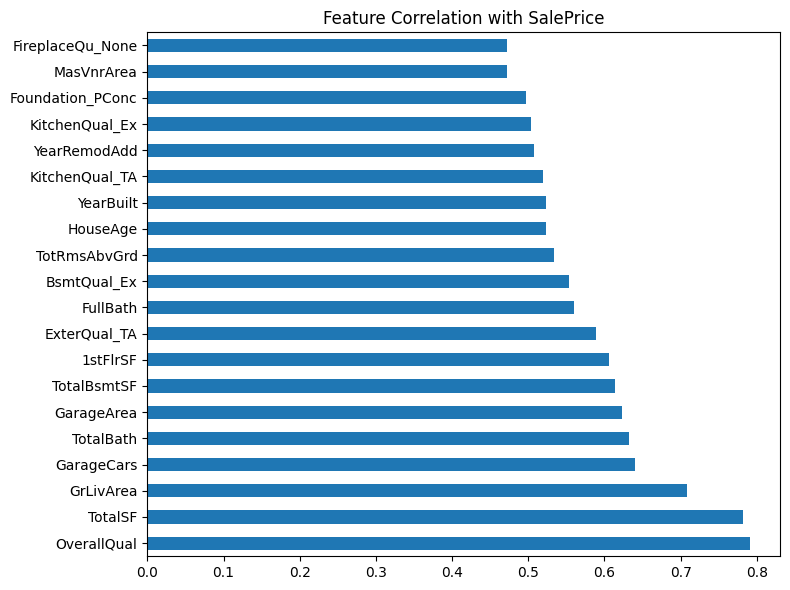

In [ ]:
import matplotlib.pyplot as plt

# Correlation of each feature with SalePrice
corr_with_target = X_train.corrwith(y_train).abs().sort_values(ascending=False)

print("Top 20 most correlated:")
print(corr_with_target.head(20))

print("\nBottom 20 least correlated (candidates to drop):")
print(corr_with_target.tail(20))

# Visualize top 20
corr_with_target.head(20).plot(kind='barh', figsize=(8, 6))
plt.title('Feature Correlation with SalePrice')
plt.tight_layout()
plt.show()

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

# VIF only makes sense on numeric/continuous features, not all 309 dummies
# Use the original numeric columns before get_dummies for VIF analysis
num_features = ['TotalSF', 'GrLivArea', 'TotalBsmtSF', '1stFlrSF',
                'GarageArea', 'LotArea', 'YearBuilt', 'HouseAge',
                'TotalBath', 'OverallQual', 'OverallCond', 'LotFrontage',
                'GarageCars', 'BsmtFinSF1', 'WoodDeckSF', 'OpenPorchSF']

X_num = X_train[num_features].dropna()

vif_df = pd.DataFrame()
vif_df['Feature'] = X_num.columns
vif_df['VIF'] = [variance_inflation_factor(X_num.values, i)
                 for i in range(X_num.shape[1])]

vif_df = vif_df.sort_values('VIF', ascending=False)
print(vif_df)

        Feature          VIF
0       TotalSF  3340.445425
1     GrLivArea  1151.875455
2   TotalBsmtSF   621.955157
6     YearBuilt    73.224886
9   OverallQual    56.665862
3      1stFlrSF    38.540110
12   GarageCars    35.099400
10  OverallCond    32.820199
4    GarageArea    29.774531
8     TotalBath    24.492817
11  LotFrontage    15.010683
7      HouseAge     5.934500
13   BsmtFinSF1     3.551665
5       LotArea     2.582043
14   WoodDeckSF     1.812266
15  OpenPorchSF     1.766122


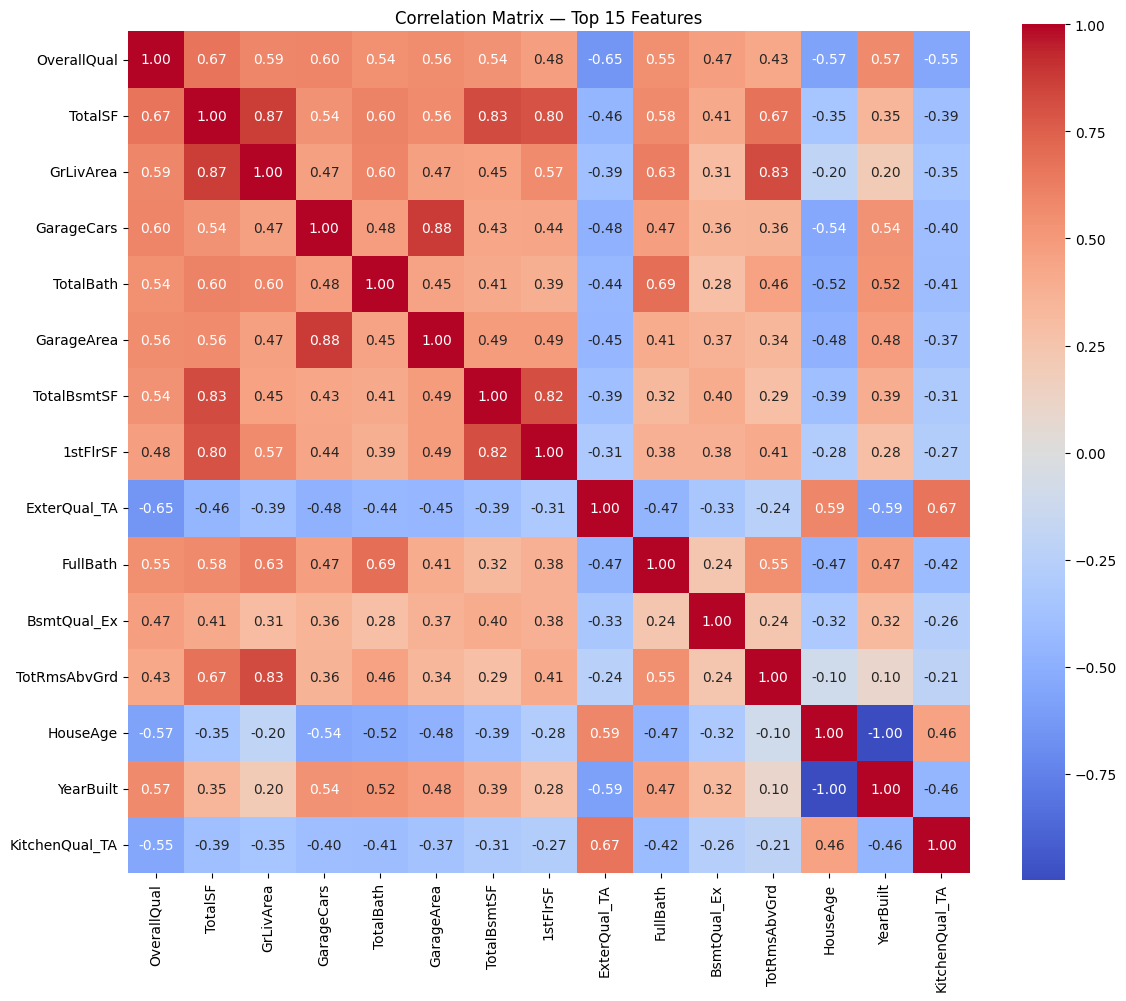

In [ ]:
import seaborn as sns

# Only do this for numeric features — a 309x309 heatmap is unreadable
top_features = corr_with_target.head(15).index.tolist()
corr_matrix = X_train[top_features].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True)
plt.title('Correlation Matrix — Top 15 Features')
plt.tight_layout()
plt.show()

In [ ]:
# Drop features with very weak correlation to SalePrice
weak_features = corr_with_target[corr_with_target < 0.05].index.tolist()
print(f"Dropping {len(weak_features)} weak features")

X_train_vt = X_train_vt.drop(columns=[c for c in weak_features if c in X_train_vt.columns])
X_test_vt  = X_test_vt.drop(columns=[c for c in weak_features if c in X_test_vt.columns])

print(f"Shape after correlation filter: {X_train_vt.shape}")

Dropping 111 weak features
Shape after correlation filter: (1460, 180)


In [ ]:
# These are sub-components already captured by TotalSF — drop them
cols_to_drop_vif = [
    '1stFlrSF',       # absorbed by TotalSF
    '2ndFlrSF',       # absorbed by TotalSF
    'TotalBsmtSF',    # absorbed by TotalSF
    'YearBuilt',      # HouseAge already captures this
    'YearRemodAdd',   # WasRemodeled captures this
    'GarageYrBlt',    # correlated with YearBuilt
    'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF',  # all sub-parts of TotalBsmtSF
    'FullBath', 'HalfBath', 'BsmtFullBath', 'BsmtHalfBath'  # absorbed by TotalBath
]

# Drop from both — check column exists first since VT may have already dropped some
X_train_vt = X_train_vt.drop(columns=[c for c in cols_to_drop_vif if c in X_train_vt.columns])
X_test_vt  = X_test_vt.drop(columns=[c for c in cols_to_drop_vif if c in X_test_vt.columns])

print(f"Shape after VIF cleanup: {X_train_vt.shape}")

Shape after VIF cleanup: (1460, 169)


In [ ]:
# After reviewing the heatmap, drop the weaker of each highly-correlated pair
cols_to_drop_corr = ['GarageCars', 'GrLivArea']
X_train_vt = X_train_vt.drop(columns=[c for c in cols_to_drop_corr if c in X_train_vt.columns])
X_test_vt  = X_test_vt.drop(columns=[c for c in cols_to_drop_corr if c in X_test_vt.columns])

print(f"Final shape: {X_train_vt.shape}")
# Target: ~80-120 columns

Final shape: (1460, 167)


In [ ]:
print("=== Final Dataset Summary ===")
print(f"X_train: {X_train_vt.shape}")
print(f"X_test:  {X_test_vt.shape}")
print(f"y_train: {y_train.shape}")

# Save final column list — important for consistency
final_cols = X_train_vt.columns.tolist()
print(f"\nFinal feature count: {len(final_cols)}")

=== Final Dataset Summary ===
X_train: (1460, 167)
X_test:  (1459, 167)
y_train: (1460,)

Final feature count: 167


In [ ]:
# Re-run correlation on the CURRENT X_train_vt (not original X_train)
corr_with_target = X_train_vt.corrwith(y_train).abs().sort_values(ascending=False)

weak_features = corr_with_target[corr_with_target < 0.05].index.tolist()
print(f"Weak features to drop: {len(weak_features)}")
print(weak_features)

X_train_vt = X_train_vt.drop(columns=weak_features)
X_test_vt  = X_test_vt.drop(columns=[c for c in weak_features if c in X_test_vt.columns])

print(f"Shape after correlation filter: {X_train_vt.shape}")

Weak features to drop: 0
[]
Shape after correlation filter: (1460, 167)


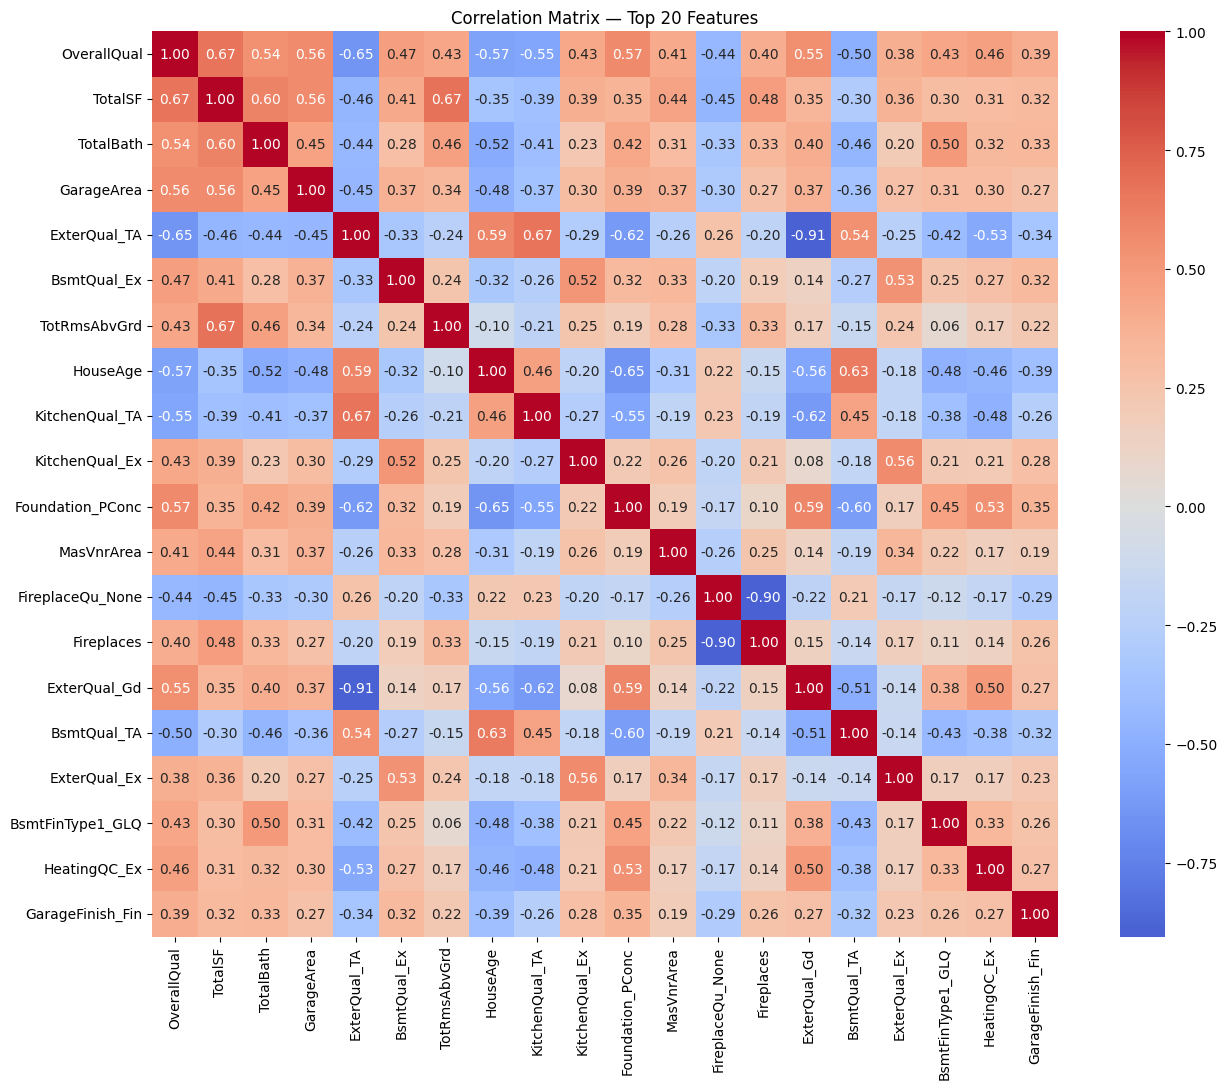

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Check top correlated features among themselves
top_features = corr_with_target.head(20).index.tolist()
corr_matrix = X_train_vt[top_features].corr()

plt.figure(figsize=(14, 11))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlation Matrix — Top 20 Features')
plt.tight_layout()
plt.show()

In [ ]:
# Likely candidates after reviewing heatmap
cols_to_drop_corr = ['GarageCars', 'GrLivArea']  # update after seeing heatmap
X_train_vt = X_train_vt.drop(columns=[c for c in cols_to_drop_corr if c in X_train_vt.columns])
X_test_vt  = X_test_vt.drop(columns=[c for c in cols_to_drop_corr if c in X_test_vt.columns])

In [ ]:
from sklearn.feature_selection import SelectKBest, f_regression

# f_regression scores each feature's linear relationship with SalePrice
selector_kb = SelectKBest(score_func=f_regression, k=100)  # keep top 100
selector_kb.fit(X_train_vt, y_train)

cols_kept = X_train_vt.columns[selector_kb.get_support()].tolist()
X_train_final = X_train_vt[cols_kept]
X_test_final  = X_test_vt[cols_kept]

print(f"Final shape: {X_train_final.shape}")
# Should be (1460, 100)

Final shape: (1460, 100)


In [ ]:
print("=== FINAL CLEAN DATASET ===")
print(f"X_train_final : {X_train_final.shape}")
print(f"X_test_final  : {X_test_final.shape}")
print(f"y_train       : {y_train.shape}")
print(f"\nTop 10 features by F-score:")
scores = pd.Series(selector_kb.scores_, index=X_train_vt.columns)
print(scores[cols_kept].sort_values(ascending=False).head(10))

=== FINAL CLEAN DATASET ===
X_train_final : (1460, 100)
X_test_final  : (1459, 100)
y_train       : (1460,)

Top 10 features by F-score:
OverallQual       2436.770591
TotalSF           2299.061790
TotalBath          968.296429
GarageArea         926.951287
ExterQual_TA       774.677019
BsmtQual_Ex        642.637454
TotRmsAbvGrd       580.762801
HouseAge           549.975877
KitchenQual_TA     538.358524
KitchenQual_Ex     496.712958
dtype: float64
